# Практика 3. Метод градиентного спуска

На этой практике мы рассмотрим как в действительности обучают линейную регрессию и познакомимся с методом градиентного спуска, который не отпустит нас на протяжении всего разговора о машинном обучении.

На самом деле линейную регрессию с точным аналитическим решением никто не использует. По простой причине: это долго. Аналитическое решение линейной регрессии находится по формуле: $$w=(X^\top X)^{-1}X^\top y.$$

Нам необходимо вычислить произведение $X^\top$ на $X$, что требует $O(d^2n)$ операций, используя самый простой алгоритмом. Также необходимо выполнять операцию обращения матрицы $(X^TX)$ размера $(d,d)$, где d $-$ это количество параметров модели (размерность вектора $w$). Время работы обращения матриц оценивается $O(d^3)$. 

Замечание о трудоёмкости нахождения аналитического решения справедливо в принципе для машинного обучения, во многих задачах и вовсе невозможно найти аналитическое решение и глобальный максимум правдоподобия.

Чаще всего применяют <b>метод градиентного спуска</b> с разными модификациями.

Метод градиентного спуска основан на минимизации <b>функции ошибки</b>. Функция ошибки - функция, минимизация которой приведёт к тому, что модель будет хорошо описывать данные. То есть, приведёт к максимизации правдоподобия. В нашем случае для линейной регрессии применяется <b>среднеквадратическая функция ошибки</b> (MSE Loss).

-------------

Пусть имеется обучающая выборка $D=\{(x_i,y_i)\}_{i=1}^n$.

Тогда среднеквадратическая функция ошибки в общем виде имеет следующий вид: $$MSELoss = \frac{1}{n}\sum_{i=1}^n(y_{i}-y_{i}')^2,$$
где $y_i'$ - предсказание модели, а в нашем случае $y_i'=x_iw$. Тогда функция ошибки для линейной регрессии обретает следующий вид: $$MSELoss = \frac{1}{n}\sum_{i=1}^n(y_{i}-w^Tx_i)^2.$$

Идея метода градиентного спуска:

- Вектор градиента функции потерь $\nabla L$ указывает направление и скорость наибольшего возрастания функции. Тогда вектор антиградиента будет указывать направление убывания функции.

- Давайте начнём в какой-то точке, к примеру сгенерируем из предполагаемого распределения весов. Далее будем совершать шаги по направлению антиградиента.

В виде формулы метод градиентного спуска записывается следующим образом:

$$w_j^{(t+1)}=w_j^{(t)}-\alpha\frac{\partial}{\partial w_j}L(X,y,w^{(t)}),$$

или в векторном виде:

$$w^{(t+1)}=w^{(t)}-\alpha\nabla_wL(w^{(t)}).$$

Для одномерного параметра это градиентный спуск можно проиллюстрировать следующим образом:

<img style="width: 50%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/dVqyLcRZ/grad-step-example.webp"/>

$w_j^{(t+1)}$ - новое значение параметра.

$w_j^{(t)}$ - старое значение параметра.

$\alpha$ - гиперпараметр (параметр алгоритма оптимизации), называемый <b>"темпом обучения"</b>. Отвечает за величину шага в направлении антиградиента. 

$L$ - MSE Loss или среднеквадратическая функция ошибки. Запишем её в матричном виде: $$L(X,y,w)=\frac{1}{n}||Xw-y||^2$$

Посчитаем градиент:

$$\nabla_wL=\frac{2}{n}X^T(Xw-y)$$

<b>Опишем алгоритм:</b>

0. Начальная инициализация параметров: $w^{(0)}$.
1. Считаем функцию ошибки: $L(X,y,w^{(t)})$.
2. Вычисляем гардиент: $\nabla_w L(X,y,w^{(t)})$.
3. Меняем параметры модели: $w^{(t+1)}=w^{(t)}-\alpha\nabla L_w(X,y,w^{(t)})$.
4. Переходим к шагу 1.

Можно заметить, что в алгоритме не описан критерий остановки.

Поэтому ограничим количество повторений цикла гиперпараметром, называемым количеством <b>эпох</b>. 

## Выбор гиперпараметров обучения

Параметр количества эпох должен быть выбран достаточно большим, чтобы "дойти" до точки минимума. А вот с темпом обучения сложнее:

<img style="width: 50%; max-width: 960px; display: block; margin: 0 auto;"  src="https://i.postimg.cc/DZH432JK/LR-example.png" width=800>


- Если темп обучения слишком низкий, то потребуется слишком много шагов, чтобы попасть в минимум. 
- Если темп обучения слишком высокий, то сходимость к минимуму может оказаться очень нестабильной. А иногда в минимум можно вовсе не попасть.


In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# Функция для отображения функции потери и спуска к оптимуму
def draw_descent(X, Y, w_true, w_list):
    radius = 3
    
    A, B = np.meshgrid(np.linspace(w_true[0] - radius, w_true[0] + radius, 200),
                       np.linspace(w_true[1] - radius,w_true[1] + radius, 200))

    W = np.vstack([A.ravel(),B.ravel()])
    
    levels = np.mean(np.power(np.dot(X, W) - Y, 2), axis=0).reshape(A.shape)
    
    plt.figure(figsize=(13, 9))
    plt.title('GD trajectory')
    plt.xlabel('$w_1$')
    plt.ylabel('$w_2$')
    wmin, wmax = w_list[:, 0].min(), w_list[:, 0].max()
    centr_x = (wmin + wmax) / 2
    width_x = np.abs(wmin - wmax)
    wmin, wmax = w_list[:, 1].min(),w_list[:, 1].max()
    centr_y = (wmin + wmax) / 2
    width_y = np.abs(wmin - wmax)
    width = np.max([width_x, width_y]) / 2 * 1.1
    plt.xlim(centr_x - width, centr_x + width)
    plt.ylim(centr_y - width, centr_y + width)
    plt.gca().set_aspect('equal')

    # visualize the level set
    CS = plt.contour(A, B, levels, levels=np.logspace(0, 2, num=100), cmap=plt.cm.rainbow_r)
    CB = plt.colorbar(CS, shrink=0.8, extend='both')

    # visualize trajectory
    plt.scatter(w_true[0], w_true[1], c='r')
    plt.scatter(w_list[:, 0], w_list[:, 1], zorder=100)
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

Численное решение: [-1.55924432 -0.00243798]
Аналитическое решение: [-1.56393599 -0.00249859]
Истинное значение: [-1.56035211 -0.0309776 ]


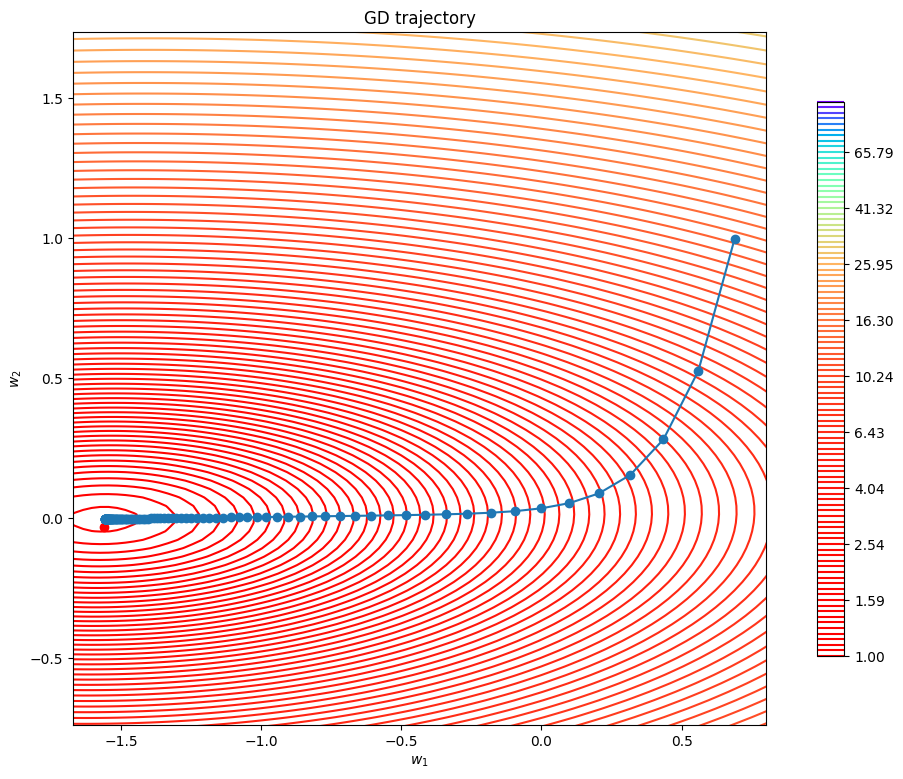

In [14]:
learning_rate = 0.03 # темп обучения
epochs = 100 # количество эпох обучения

n_dim = 2 # степень полинома
w_true = np.random.normal(0, 1, (n_dim, 1)) # настоящие параметры модели
# генерируем выборку
num_samples = 500  # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 100
x = np.hstack([np.ones((num_samples, 1)),
        np.random.uniform(-5, 5, (num_samples, n_dim - 1))])
    
y = x @ w_true + np.random.normal(0, sigma, (num_samples, 1))

w = np.random.normal(0, 1, (n_dim, 1))
w_list = [w.copy()]

for i in range(0,epochs):
    # Вычислите градиент
    grad = 2 / num_samples * x.T @ (x @ w - y) 
    # Измените параметры модели
    w = w - learning_rate * grad
    # Сохраняем веса в список
    w_list.append(w.copy())

w_exact = (np.linalg.inv(x.T @ x) @ x.T @ y)
print(f"Численное решение: {w.ravel()}")
print(f"Аналитическое решение: {w_exact.ravel()}")
print(f"Истинное значение: {w_true.ravel()}")
draw_descent(x, y, w_true, np.array(w_list))

## Метод Ньютона

Что будет, если признаки X будут иметь разный масштаб? Тогда эллиптический параболоид, возникающий из среднеквадратический функции ошибки будет сплюснут по одной из координат. И в этот момент возникает проблема с параметром темпа обучения. 

Из-за того, что параметр темпа обучения одинаков для всех параметров $w_i$, то окажется, что по одной координате шаг может быть слишком большим, а по другой координате - слишком маленьким. 

В примере ниже, где соотношение "сторон" чуть менее 2-х, оказывается, что по одной координате ($w_1$) темп обучения вполне подходящий, а по другой ($w_2$) - слишком высокий. И в итоге градиентный спуск расходится. 

А разность масштаба признаков сплошь и всюду. К примеру, мы по росту (в см.) и весу(в кг.) хотим предсказать возраст человека. Скорее всего вес человека раза в 2-3 меньше роста человека и уже может возникнуть проблемы. А если добавить в модель признак "зароботок"(в рублях), то проблемы уже точно гарантированы.

Простым уменьшением темпа обучения эту проблему не решить. Можно увеличить кривизну параболоида и добиться ситуации, когда по одной координате градиентный спуск будет расходится, а по другой потребует слишком много итераций, чтобы достигнуть минимума. А в случае, если признаков не 2, а 100, найти оптимальный темп обучения может быть затруднительно.

[[-0.28911866]
 [ 0.11443867]]
Численное решение: [-0.31257699 -0.79178541]
Аналитическое решение: [-0.28911866  0.11443867]
Истинное значение: [-0.29050317  0.11212805]


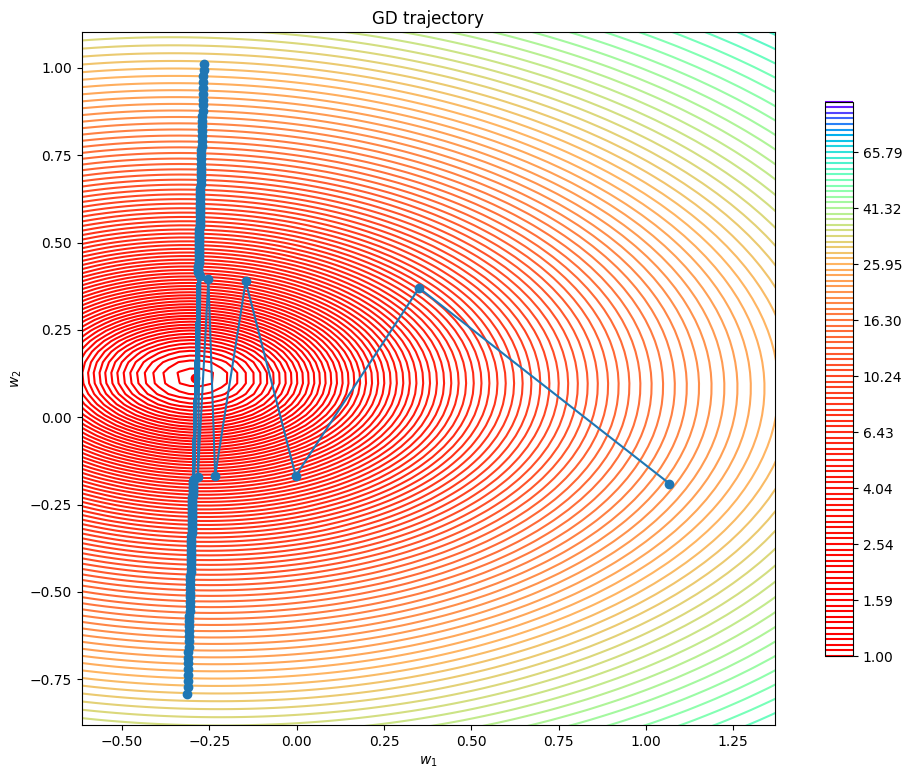

In [15]:
learning_rate = 0.03 # темп обучения
epochs = 120 # количество эпох обучения
np.random.seed(51)

n_dim = 2 # степень полинома
w_true = np.random.normal(0, 1, size=(n_dim, 1)) # настоящие параметры модели

# генерируем выборку
num_samples = 500  # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 100
x = np.concatenate([np.random.normal(0, 3, (num_samples, n_dim-1)),
                    np.random.normal(0, 5.85, (num_samples, 1))],axis=1)

y = x @ w_true + np.random.normal(0, sigma, (num_samples, 1))

w = np.random.normal(0, 1,size=(n_dim,1))
w_list = [w.copy()]

for i in range(0,epochs):
    # Вычислите градиент
    grad = 2 / num_samples * x.T @ (x @ w - y)
    # Измените параметры модели
    w = w - learning_rate * grad
    # Сохраняем веса в список
    w_list.append(w.copy())

w_exact = (np.linalg.inv(x.T @ x) @ x.T @ y)
print(w_exact)
print(f"Численное решение: {w.ravel()}")
print(f"Аналитическое решение: {w_exact.ravel()}")
print(f"Истинное значение: {w_true.ravel()}")
draw_descent(x, y, w_true, np.array(w_list))

Одним решением может быть приведение величин к одному масштабу. К примеру, можно вычесть среднее  и поделить на стандартное отклонение. И так правда часто делают, но в некоторых случаях это может быть не уместно. Иногда такую операцию нельзя делать из соображений о смысле переменных. 

Решение данной проблемы состоит в применении <b>метода Ньютона</b>, основанного на второй производной. Он позволит "выбрать" величину градиентного шага по каждому направлению отдельно.

Для этого необходимо разложить функцию ошибки в ряд Тейлора до второго члена:

$$L(w) \approx L(w^{(t)})+\nabla_w L(w^{(t)})^T(w-w^{(t)})+\frac{1}{2}(w-w^{(t)})^TH_t(w-w^{(t)}),$$

$$H_k=\nabla_w^2L(w^{(t)})=\begin{pmatrix}
\frac{\partial^2L(w^{(t)})}{\partial w_1^2} & \frac{\partial^2L(w^{(t)})}{\partial w_1 \partial w_2} & \dots & \frac{\partial^2L(w^{(t)})}{\partial w_1 \partial w_d}\\
\frac{\partial^2L(w^{(t)})}{\partial w_2 \partial w_1} & \frac{\partial^2L(w^{(t)})}{\partial w_2^2} & \dots & \frac{\partial^2L(w^{(t)})}{\partial w_1 \partial w_d}\\
\vdots & \vdots & \ddots & \vdots\\
\frac{\partial^2L(w^{(t)})}{\partial w_d \partial w_1} & \frac{\partial^2L(w^{(t)})}{\partial w_d \partial w_2} & \dots & \frac{\partial^2L(w^{(t)})}{\partial w_d^2}\\
\end{pmatrix}.$$

$H_k$ называют Гессианом, это матрица вторых производных.

Далее вычислим градиент по $w$. Необходимо расписать $w=(w_1,\dots,w_d)$ и посчитать частные производные $\frac{\partial}{\partial w_i}$. Мы это опустим, а вы <b>сделаете это дома</b> в качестве упражнения. Результат:

$$\nabla_w L(w) = \nabla_w L(w^{(t)}) + H_t (w-w^{(t)}).$$

Далее приравняем градиент к 0 и умножим слева на матрицу $H_t^{-1}$:

$$0 = H_t^{-1} \nabla_w L(w^{(t)}) + w-w^{(t)}.$$

Получим:

$$w^{(t+1)} = w^{(t)} - H_t^{-1} \nabla_w L(w^{(t)}).$$

То есть мы строим приближение нашей функции ошибки с помощью параболоида и смещаемся в точку минимума этого параболоида.

<img style="width: 50%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/qvtqBGRJ/newton-method1.png"/>

Но есть один нюанс... Метод ньютона не ведёт нас в минимум, он ведёт нас в экстремум.

<img style="width: 50%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/V6wkRQFv/newton-method2.png"/>

Есть разные методы борьбы с этим, но мы их опустим. В случае линейной регрессии всё прекрасно: минимум всего один и функция всюду выпукла. Но это ещё не всё. В случае линейной регрессии сама функция ошибки и её приближение рядом тейлора второй степени в точности совпадают, а значит сходимость в минимум достигается всего за один шаг!

<img style="width: 50%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/3RZJfSLB/newton-method4.png"/>

А вот пример нескольких шагов метода Ньютона на примере функции $x^4 + \frac{4}{5}x^2 + \frac{1}{10}x$:

<img style="width: 50%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/GmZ24s8k/newton-method3.png"/>

А теперь реализуем метод Ньютона!

Численное решение: [-0.28634964  0.11280391]
Аналитическое решение: [-0.28634964  0.11280391]
Истинное значение: [-0.29050317  0.11212805]


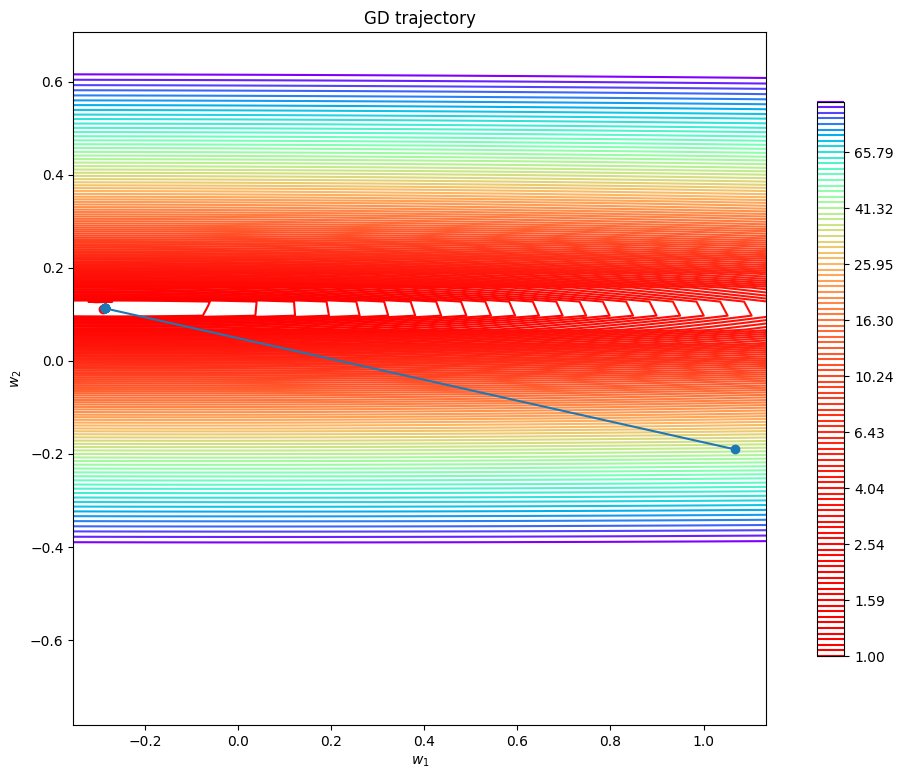

In [16]:
epochs = 10 # количество эпох обучения
np.random.seed(51)

n_dim = 2 # степень полинома
w_true = np.random.normal(0, 1, size=(n_dim, 1)) # настоящие параметры модели

# генерируем выборку
num_samples = 500  # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 100
x = np.concatenate([np.random.normal(0, 1, (num_samples, n_dim-1)),
                    np.random.normal(0, 20, (num_samples, 1))],axis=1)

y = x @ w_true + np.random.normal(0, sigma, (num_samples, 1))

w = np.random.normal(0, 1, size=(n_dim, 1))
w_list = [w.copy()]

for i in range(0,epochs):
    # Вычислите градиент
    grad = 2 / num_samples * x.T @ (x @ w - y)
    H = 2 / num_samples * x.T @ x
    # Измените параметры модели
    w = w - np.linalg.inv(H) @ grad 
    # Сохраняем веса в список
    w_list.append(w.copy())

w_exact = (np.linalg.inv(x.T @ x) @ x.T @ y)
print(f"Численное решение: {w.ravel()}")
print(f"Аналитическое решение: {w_exact.ravel()}")
print(f"Истинное значение: {w_true.ravel()}")
draw_descent(x, y, w_true, np.array(w_list))

Проблема кривизны решилась и сходимость к минимуму и правда достигается всего за один шаг!

## Задание:

Реализуйте класс, в котором будет возможность обучить линейную регрессию. Необходима возможность выбрать регуляризацию: без, $L_1$, $L_2$. Необходима возможность включения метода ньютона для обучения.

Если пространство весов двумерное, необходима возможность визуализации обучения: отрисовка линий уровня функции потери и линий уровня регуляризации, отрисовка пути изменения весов.

Подсказка:

|  Регуляризация  | Функция ошибки | Градиент | Гессиан |
|-----------------|----------------|----------|---------|
| Нет             | $\frac{1}{n}(Xw-y)^T(Xw-y)$             | $\frac{2}{n}X^T(Xw-y)$    | $\frac{2}{n}X^TX$ |
| $L_2$              | $+\alpha\sum_{i=1}^{d} w_i^2$           | $+2\alpha w$              | $+2\alpha E$      |
| $L_1$              | $+\alpha\sum_{i=1}^{d}\mid w_i \mid$    | $+\alpha sign(w)$         | Не существует     |


-------

$$
sign(w) = sign
\left(
    \begin{pmatrix}
    w_1\\
    \vdots\\
    w_d
    \end{pmatrix}
\right)
=
\begin{pmatrix}
    sign(w_1)\\
    \vdots\\
    sign(w_d)
    \end{pmatrix}
;\; sign(w_i)=\begin{cases}1,&  w_i>0\\-1,&  w_i<0\end{cases}$$

Стоит заметить, что при $L_1$ регуляризации градиент не существует, если одна из координат $w_i$ равна 0. Но нас этот момент волновать не будет. Равенство какого-то веса 0 можно пренебречь и считать градиент нулевым. 

А вот применять метод Ньютона для регрессии с $L_1$ регуляризацией нельзя из-за того, что функция потери становится не гладкой.

In [17]:
from typing import Literal

class Regressor:
    
    def __init__(self, lr=0.001,
                 lr_decay=False,
                   epochs=100,
                     use_newton = False,
                       regularization:Literal["None","L1","L2"]="None",
                         alpha=0.1,
                         use_stohastic_grad = False,
                         batch_size = 1):
        self.lr = lr
        self.lr_decay = lr_decay
        self.epochs = epochs
        self.use_newton = use_newton
        self.regularization = regularization
        self.alpha = alpha
        self.w_list = []
        self.w = None
        self.use_stohastic_grad = use_stohastic_grad
        self.batch_size = batch_size
        if self.regularization == "L1" and self.use_newton:
            raise Exception("Метод ньютона не применим к L1 регуляризации.")
    
    def loss(self, x:np.ndarray, y:np.ndarray, w:np.ndarray):
        n = len(x)
        mse = x @ w - y
        ans = 1 / n  * np.sum(np.square(mse), axis=0)
        if self.regularization == "None":# отдельно компонента функции ошибки и регуляризации для удобной отрисовки
            return [ans, np.zeros_like(ans)]
        elif self.regularization == "L2":
            return [ans + self.alpha * np.sum(w**2, axis=0),  self.alpha * np.sum(w**2, axis=0)]
        elif self.regularization == "L1":
            return [ans + self.alpha * np.sum(np.abs(w), axis=0), self.alpha * np.sum(np.abs(w), axis=0)]
            
    def grad(self, x:np.ndarray, y:np.ndarray, w:np.ndarray):
        if self.regularization == "None" and self.use_stohastic_grad == False:
            return 2 / len(x) * x.T @ (x @ w - y)
        elif self.regularization == "L2":
            return 2 / len(x) * x.T @ (x @ w - y) + 2 * self.alpha * w
        elif self.regularization == "L1":
            return 2 / len(x) * x.T @ (x @ w - y) + self.alpha * np.sign(w)
        else:
            return 2 / self.batch_size * x.T @ (x @ w - y)
        
    def hessian(self, x:np.ndarray, y:np.ndarray, w:np.ndarray):
        if self.regularization == "None":
            return 2 / len(x) * x.T @ x 
        elif self.regularization == "L2":
            return 2 / len(x) * x.T @ x + 2 * self.alpha * np.identity(x.shape[1])
    
    def init_w(self, n_dim):
        """ Функция начальной инициализации весов."""
        return np.random.normal(0, 1, (n_dim, 1))
    
    def fit(self, x, y):
        # инициализация весов
        w = self.init_w(x.shape[1])
        w_list = [w]
        # Цикл обучения
        if self.use_stohastic_grad == False:
            for i in range(0, self.epochs):
                # Вычисление градиента
                grad = self.grad(x, y, w)
                # Измените параметры модели
                if self.use_newton:
                    # Вычисление Гессиана
                    H = self.hessian(x, y, w)
                    w = w - np.linalg.inv(H) @ grad
                else:
                    w = w - self.lr * grad
                # Сохраняем веса в список
                w_list.append(w.copy())
                if self.lr_decay:
                    self.lr *=0.95
            self.w_list = np.array(w_list)
            self.w = w
        else:
            indexes = np.arange(x.shape[0])
            learning_rate = self.lr
            for i in range (0, self.epochs):
                np.random.shuffle(indexes)
                for j in range(0, x.shape[0] // self.batch_size):
                    indices = indexes[j * self.batch_size: (j+1) * self.batch_size]
                    grad = self.grad(x[indices], y[indices], w)
                    w = w - learning_rate * grad
                    w_list.append(w.copy())
                    learning_rate = learning_rate * 0.98
            self.w_list = np.array(w_list)
            self.w = w
            
    def predict(self, x):
        return x @ self.w
    
    def show_training(self, w_true, x, y):
        if self.w.shape[0] !=2:
            raise Exception("Веса должны быть размерности 2.")
        radius = 2
    
        A, B = np.meshgrid(np.linspace(w_true[0] - radius, w_true[0] + radius, 200),
                        np.linspace(w_true[1] - radius, w_true[1] + radius, 200))

        W = np.vstack([A.ravel(), B.ravel()])
        
        loss, reg = self.loss(x, y, W)
        levels_loss = loss.reshape(A.shape)
        levels_reg = reg.reshape(A.shape)
        
        plt.figure(figsize=(13, 9))
        plt.title('GD trajectory')
        plt.xlabel('$w_1$')
        plt.ylabel('$w_2$')
        wmin, wmax = self.w_list[:, 0].min(),self.w_list[:, 0].max()
        centr_x = (wmin + wmax) / 2
        width_x = np.abs(wmin - wmax)
        wmin, wmax = self.w_list[:, 1].min(),self.w_list[:, 1].max()
        centr_y = (wmin + wmax) / 2
        width_y = np.abs(wmin - wmax)
        width = np.max([width_x, width_y]) / 2 * 1.1
        plt.xlim(centr_x - width, centr_x + width)
        plt.ylim(centr_y - width, centr_y + width)
        # plt.gca().set_aspect('equal')

        # visualize the level set
        CS = plt.contour(A, B, levels_loss, levels=np.logspace(0, 2, num=50), cmap=plt.cm.rainbow_r)
        CB = plt.colorbar(CS, shrink=0.8, extend='both')
        CS = plt.contour(A, B, levels_reg, levels=np.linspace(0, 5*self.alpha, num=50), cmap=plt.cm.brg)

        # visualize trajectory
        plt.scatter(self.w_list[:, 0], self.w_list[:, 1], color="black")
        plt.plot(self.w_list[:, 0], self.w_list[:, 1], color="black")

        plt.show()

Пример результатов работы класса:

In [18]:
# np.random.seed(51)

n_dim = 2 # степень полинома
w_true = np.random.normal(0, 1, size=(n_dim, 1)) # настоящие параметры модели
w_true = np.array([[0.4],[-0.1]])

# генерируем выборку
num_samples = 500  # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 100
x = np.concatenate([np.random.normal(0, 1, (num_samples, n_dim-1)),
                    np.random.normal(0, 1, (num_samples, 1))],axis=1)

y = x @ w_true + np.random.normal(0, sigma, (num_samples, 1))

Пример с $L_1$ регуляризацией:

Обученные веса: [ 0.39159222 -0.0839359 ]
Настоящие веса: [ 0.4 -0.1]


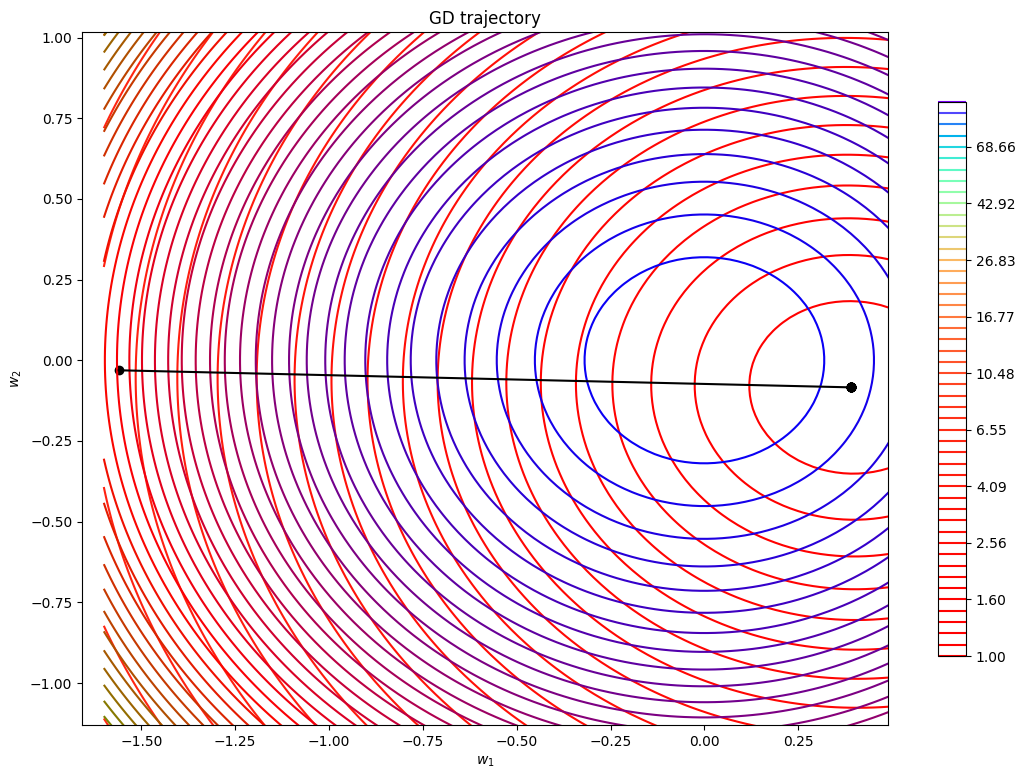

In [19]:
np.random.seed(50)
r = Regressor(lr=0.1, lr_decay=True, epochs=20, use_newton=True, regularization="L2", alpha=0.1)
r.fit(x, y)

print(f"Обученные веса: {r.w.ravel()}")
print(f"Настоящие веса: {w_true.ravel()}")
r.show_training(w_true, x, y)

$L_2$ регуляризация 

Обученные веса: [ 0.39159222 -0.0839359 ]
Настоящие веса: [ 0.4 -0.1]


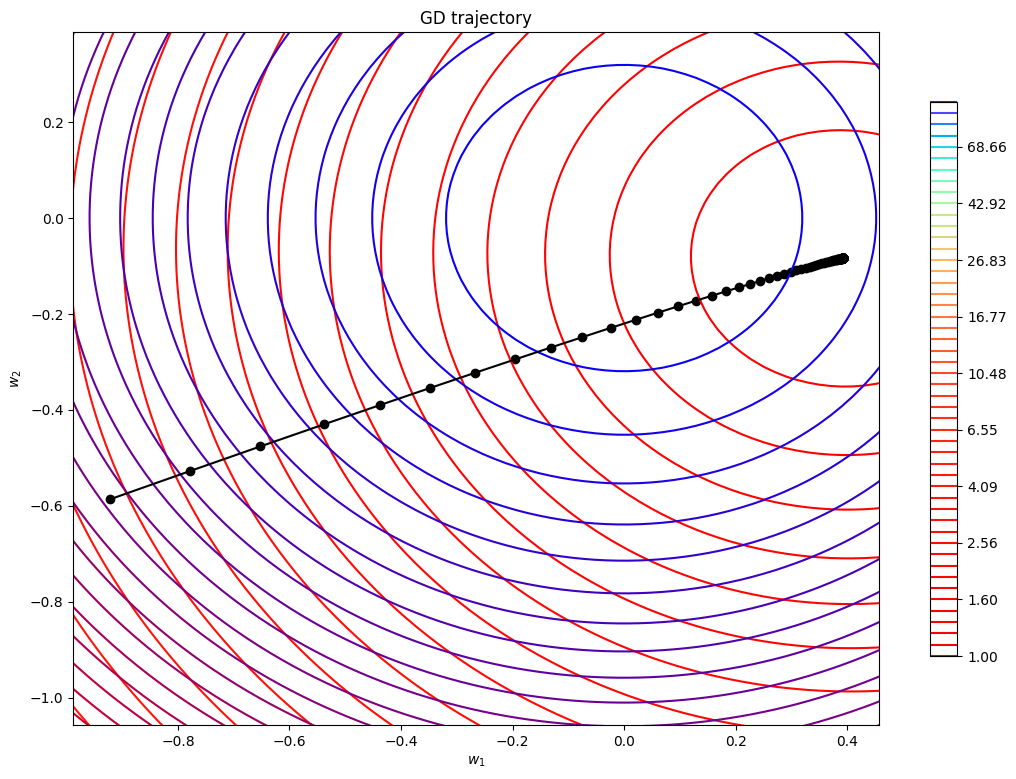

In [10]:
np.random.seed(60)
r = Regressor(lr=0.05, lr_decay=False, epochs=200, use_newton=False, regularization="L2", alpha=0.1)
r.fit(x, y)

print(f"Обученные веса: {r.w.ravel()}")
print(f"Настоящие веса: {w_true.ravel()}")
r.show_training(w_true, x, y)

$L_2$ регуляризация с методом Ньютона и большим перекосом в масштабе данных.

Обученные веса: [ 0.33931295 -0.20119105]
Настоящие веса: [ 0.4 -0.2]


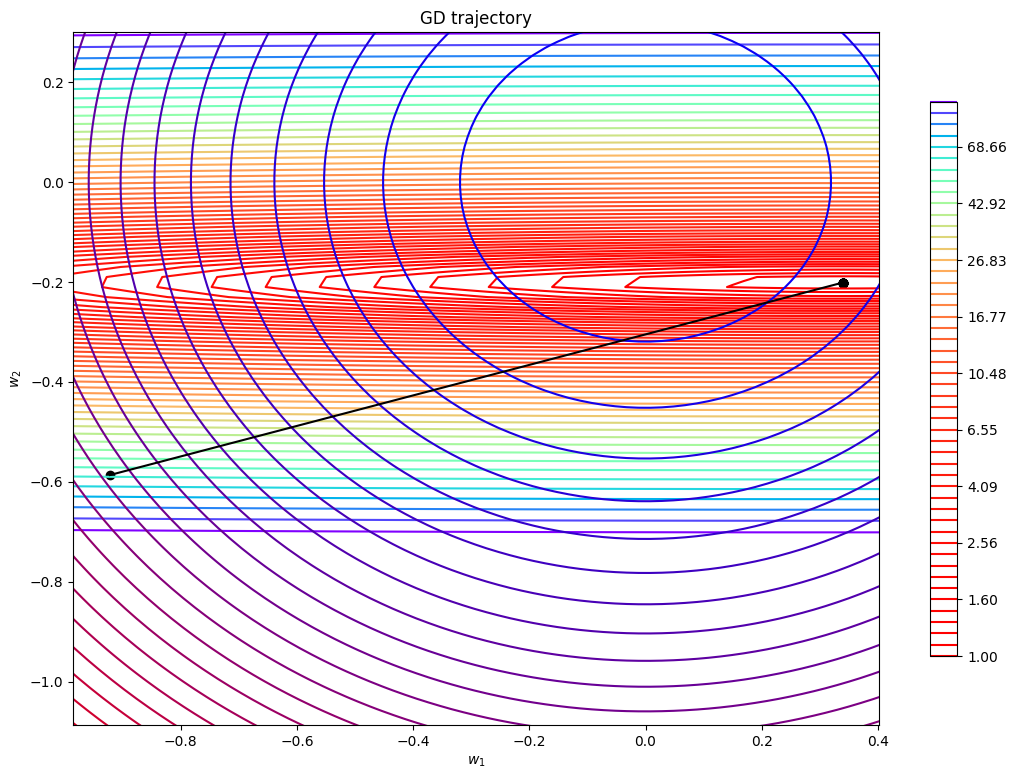

In [111]:
n_dim = 2 # степень полинома
w_true = np.random.normal(0, 1, size=(n_dim, 1)) # настоящие параметры модели
w_true = np.array([[0.4], [-0.2]])

# генерируем выборку
num_samples = 500  # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 100
x = np.concatenate([np.random.normal(0, 1, (num_samples, n_dim-1)),
                    np.random.normal(0, 20, (num_samples, 1))],axis=1)

y = x @ w_true + np.random.normal(0, sigma, (num_samples, 1))

np.random.seed(60)
r = Regressor(epochs=20, use_newton=True, regularization="L2", alpha=0.001)
r.fit(x, y)

print(f"Обученные веса: {r.w.ravel()}")
print(f"Настоящие веса: {w_true.ravel()}")
r.show_training(w_true, x, y)

На этом примере можно снова отметить, что метод Ньютона для Ridge-регрессии снова сошёлся за один шаг. 

## Стохастический градиентный спуск

Стоит отметить, что метод Ньютона имеет очень ограниченное применение. 
- Как уже отмечалось выше, он не применим если функция не гладкая
- Метод ньютона ведёт в экстремум, а не в минимум.
- Требует обращения квадратной матрицы размера $(d,d)$.

Касаемо применения метода Ньютона в <b>нейронных сетях</b> больше всего проблем доставляет именно последний пункт. Как правило, вектор весов в нейронных сетях огромен. К примеру, в GPT-4 количество весов оценивается числом $10^{14}$, а в простых вариантах свёрточных нейронных сетей, которые мы пообучаем уже на другом курсе, обычно содержится несколько миллионов весов. Поэтому вычисление Гессиана становится непосильной задачей. Стоит отметить, что существуют квазиньютоновские методы, которые строят приближения Гессиана при помощи значений самой функции ошибки и её градиента. Но применять их тоже не удаётся. Для хорошего приближения необходимо хотя-бы знать значение градиента функции, но даже этого не удаётся. А связано это с темой нашего следующего разговора.

В реальных задачах машинного обучения наборы данных, действительно позволяющие решать задачи, огромны. Классический набор данных для классификации изображений, [ImageNet](https://image-net.org/download.php) содержит более миллиона изображений. А для получения градиента функции ошибки необходимо посчитать градиент для каждой точки данных и усреднить их. Так, даже вычисление градиента всей функции ошибки оказывается трудоёмким занятием как касательно затрачиваемого времени, так и касательно необходимых затрат памяти. К примеру, тот же набор данных ImageNet Весит примерно 160ГБ, а для вычисления градиента нам эти данные надо записать в память и произвести некоторые операции.

Решением проблемы становится применение <b>стохастического градиентного спуска</b> (stochastic gradient descent, SGD), который за один шаг оптимизации вычисляет градиент не по всей выборке, а по некоторой подвыборке. 

Математически это можно обосновать следующим образом: минимизация функции ошибки это минимизация матожидания ошибки по выборке (Если считать, что элементы данных выбираются равномерно):

$$L(w)=\frac{1}{n}\sum_{i=1}^{n}f_i(w)=\mathbb{E}_{i\sim Unif(1,...,N)}f_i(w).$$

В свою очередь, метод стохастического градиентного спуска строит оценки матожидания функции ошибки на основании среднего по подвыборке:

$$\hat{L}(w)=\frac{1}{m}\sum_{i=1}^{m}f_{j_i}(w)$$

где $j_1,\dots,j_m$ - подвыборка, сгенерированная равномерно.

Стоит отметить, что получаемые оценки имеют хорошие свойства, они состоятельные и несмещённые.

Наконец, на основании оценки функции ошибки можно построить оценку градиента функции ошибки:

$$\nabla_w\hat{L}(w)=\frac{1}{m}\sum_{i=1}^{m}\nabla_wf_{j_i}(w).$$

Тем не менее стоит отметить, что дисперсия такой оценки при небольшом размере подвыборки будет велика. Тут уже видна проблема применеия квазиньютоновских методов. Из-за большой дисперсии оценки градиента оценка Гессиана оказывается неприменимой.

По той же причине большой дисперсии стохастический градиентный спуск никогда не будет двигаться в точности в правильном направлении. Также даже в точке оптимума оценка градиента не будет равна 0 и алгоритм продолжит блуждать в окрестности минимума. А размер окрестности будет зависеть от параметра темпа обучения.

Из-за проблемы блуждания в окрестности минимума имеет смысл по ходу алгоритма уменьшать темп обучения. Точного ответа как именно необходимо уменьшать темп обучения нет. Можно использовать стандартные зависимости: 
 - линейная:
 $$\alpha=\alpha_0\left(1-\frac{t}{T}\right),$$
 - экспоненциальная:
 $$\alpha=\alpha_0e^{-\frac{t}{T}}.$$

Реализуйте стохастический градиентный спуск: равномерно сгенерируйте подвыборку и посчитайте по ней градиент.

Опробуйте разные параметры размера подвыборки, темпа обучения и способа уменьшения темпа обучения.

Обновлённый алгоритм градиентного спуска будет выглядеть так:

0. Начальная инициализация параметров: $w^{(0)}$.
1. Генерация подвыборки $X'$ и $y'$.
2. Вычисляем гардиент: $\nabla L_w(X',y',w^{(t)})$.
3. Меняем параметры модели: $w^{(t+1)}=w^{(t)}-\alpha\nabla L_w(X',y',w^{(t)})$.
4. Обновляем темп обучения $\alpha$.
5. Переходим к шагу 1.

Численное решение: [ 1.085213   -1.23372859]
Аналитическое решение: [ 1.14622754 -1.23305539]
Истинное значение: [ 1.16399914 -1.24172396]


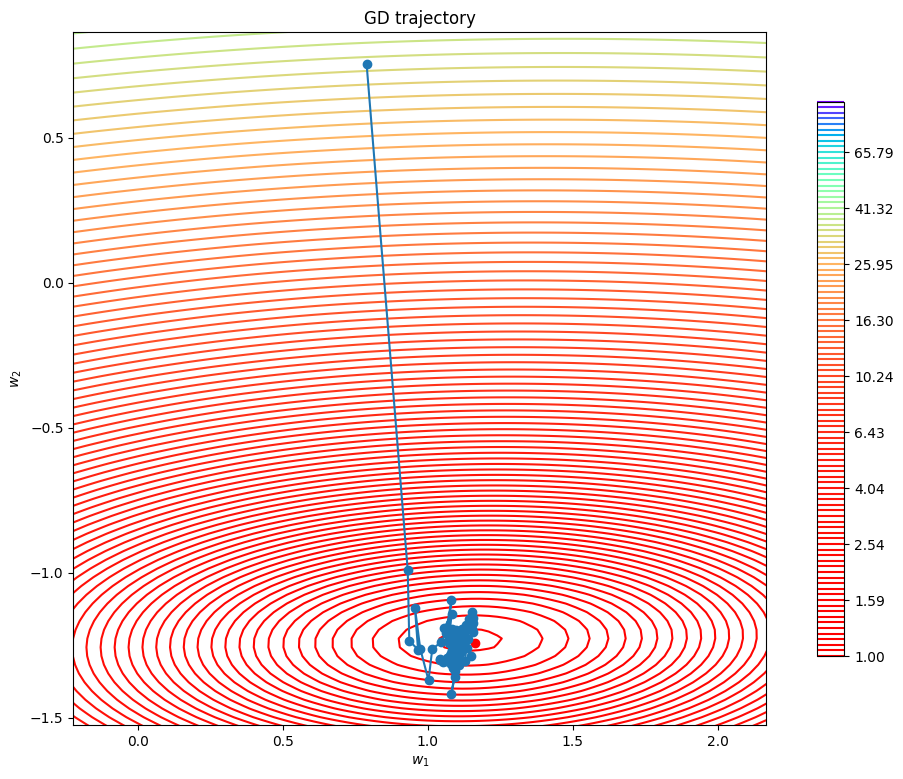

In [112]:
learning_rate = 0.05 # темп обучения
epochs = 100 # количество эпох обучения
batch_size = 10 # размер подвыборки

n_dim = 2 # степень полинома
w_true = np.random.normal(0, 1, (n_dim, 1)) # настоящие параметры модели
# генерируем выборку
num_samples = 500  # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 100
x = np.hstack([np.ones((num_samples, 1)),
        np.random.uniform(-5, 5, (num_samples, n_dim - 1))])
    
y = x @ w_true + np.random.normal(0, sigma, (num_samples, 1))

w = np.random.normal(0, 1, (n_dim, 1))
w_list = [w.copy()]

for i in range(0,epochs):
    # Вычисляем градиент
    indices = np.random.randint(0,x.shape[0], batch_size)
    grad = 2 / batch_size * x[indices].T @ (x[indices] @ w - y[indices])
    # Изменяем параметры модели
    w = w - learning_rate * grad
    # Сохраняем веса в список
    w_list.append(w.copy())
    learning_rate = learning_rate * 0.98

w_exact = (np.linalg.inv(x.T @ x) @ x.T @ y)
print(f"Численное решение: {w.ravel()}")
print(f"Аналитическое решение: {w_exact.ravel()}")
print(f"Истинное значение: {w_true.ravel()}")
draw_descent(x, y, w_true, np.array(w_list))

<b>Замечание</b>

Важно отметить, что ранее <i>количеством эпох</i> мы называли количество шагов обновления градиента, и это и правда было так. Обычно же под количеством эпох понимают количество проходов вычисления градиента по всей выборке. 

Для этого надо создать массив индексов от $0$ до $n$ и перемешать. Далее необходимо проитерироваться по этому массиву и вычислить градиенты по подвыборкам.

Заметьте насколько стохастический градиентный спуск быстрее обычного: 
- Сократились затраты по памяти, а при обучении нейронных сетей это одна из больших проблем;
- Сократились затраты по времени на вычисление градиента;
- После прохода по всей выборке будет сделан не один градиентный шаг, а целых $\frac{n}{batch\_size}$.

Обученные веса: [-0.03428515  1.19127156]
Настоящие веса: [-0.06459555  1.1817615 ]


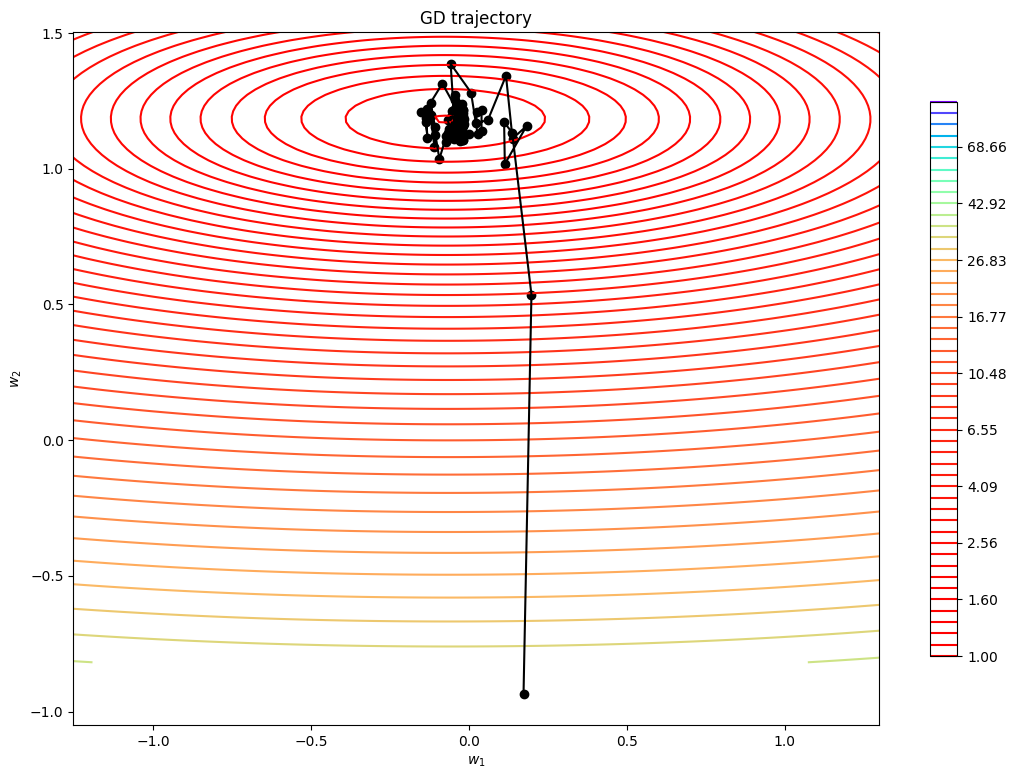

In [117]:
learning_rate = 0.05 # темп обучения
epochs = 10 # количество эпох обучения
batch_size = 10 # размер подвыборки

n_dim = 2 # степень полинома
w_true = np.random.normal(0, 1, (n_dim, 1)) # настоящие параметры модели
# генерируем выборку
num_samples = 5000  # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 100
x = np.hstack([np.ones((num_samples, 1)),
        np.random.uniform(-5, 5, (num_samples, n_dim - 1))])
    
y = x @ w_true + np.random.normal(0, sigma, (num_samples, 1))



r = Regressor(epochs=10, use_stohastic_grad=True, lr=0.05, batch_size=10)
r.fit(x, y)
print(f"Обученные веса: {r.w.ravel()}")
print(f"Настоящие веса: {w_true.ravel()}")
r.show_training(w_true, x, y)

<b>Задание</b>: доработайте класс `Regressor`, добавьте реализацию стохастического градиентного спуска, добавьте механизм уменьшения темпа обучения. Посмотрите как работает метод Ньютона в комбинации с стохастическим градиентным спуском?

# Домашнее задание

- Расписать частную производную для Гессиана. Ранее в тексте упоминалось, что задание расписать одну формулу идёт на дом.
- Написать класс для обучения линейной регрессии с разными регуляризациями и методом Ньютона. Необходимо доработать предоставленный класс Regressor.
- Дополнить класс реализацией стохастического градиентного спуска.